# Trader Performance vs Market Sentiment Analysis

## Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader behavior on the Hyperliquid platform.

This analysis aims to answer the following questions:

- Does trader profitability change during Fear and Greed market conditions?
- Do traders alter their behavior (trade frequency, leverage, position size, long/short bias) based on market sentiment?
- Which trader segments perform best under different market conditions?
- What actionable trading strategies can be derived from the analysis?

The project combines the Bitcoin Fear & Greed Index dataset with historical Hyperliquid trading data to generate insights using Python and data visualization.

In [151]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [61]:
hist_data = pd.read_csv("../data/historical_data.csv")
fear_greed_data = pd.read_csv("../data/fear_greed_index.csv")

In [62]:
hist_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [63]:
fear_greed_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [64]:
hist_data.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [65]:
fear_greed_data.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [66]:
fear_greed_data.shape

(2644, 4)

In [67]:
hist_data.shape

(211224, 16)

In [68]:
hist_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [69]:
fear_greed_data.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [70]:
hist_data.dtypes


Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [71]:
fear_greed_data.dtypes

timestamp         int64
value             int64
classification      str
date                str
dtype: object

In [72]:
hist_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [73]:
fear_greed_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [74]:
hist_data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [75]:
fear_greed_data.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [76]:
hist_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [77]:
fear_greed_data.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [78]:
hist_data.duplicated().sum()

np.int64(0)

In [79]:
fear_greed_data.duplicated().sum()

np.int64(0)

In [80]:
hist_data["Closed PnL"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Closed PnL, dtype: float64

In [81]:
hist_data[["Coin","Closed PnL"]].head()

,Coin,Closed PnL
0,@107,0.0
1,@107,0.0
2,@107,0.0
3,@107,0.0
4,@107,0.0


In [82]:
type(hist_data["Coin"])

pandas.Series

In [83]:
type(hist_data[["Coin"]])

pandas.DataFrame

In [84]:
hist_data[hist_data["Direction"] == "Open Long"]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
64,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.030,7.47,1755.67,BUY,03-12-2024 14:42,0.00,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.614485,7.750000e+14,1.730000e+12
65,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.040,9.02,2120.06,BUY,03-12-2024 14:42,7.47,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.742021,5.420000e+14,1.730000e+12
66,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.040,7.72,1814.51,BUY,03-12-2024 14:42,16.49,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.635078,6.300000e+14,1.730000e+12
67,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.090,3.66,860.43,BUY,03-12-2024 14:42,24.21,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.301150,8.490000e+14,1.730000e+12
68,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.090,15.45,3632.14,BUY,03-12-2024 14:42,27.87,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,1.271249,7.960000e+14,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211086,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.154,600.10,692.52,BUY,23-04-2025 15:30,96335.10,Open Long,0.0,0x8fea713978b76316eaec042216cffe02048100b95383...,88264995359,False,0.069251,3.170000e+14,1.750000e+12
211087,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.154,455.10,525.19,BUY,23-04-2025 15:30,96935.20,Open Long,0.0,0x23b6fa667f348fbbdba0042216cfff0203cd0069f202...,88264995359,False,0.052518,8.770000e+14,1.750000e+12
211088,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.154,2295.00,2648.43,BUY,23-04-2025 15:30,97390.30,Open Long,0.0,0x01515f86120564623856042216cfff0203d7000563f7...,88264995359,False,0.264843,5.190000e+14,1.750000e+12
211089,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.154,13.00,15.00,BUY,23-04-2025 15:30,99685.30,Open Long,0.0,0x6b6eabeae957826a529b042216d0000202b400210200...,88264995359,False,0.001500,8.720000e+13,1.750000e+12


In [85]:
fear_greed_data["date"]

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: str

In [86]:
hist_data["Timestamp IST"] = pd.to_datetime(hist_data["Timestamp IST"],dayfirst=True)

In [87]:
hist_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [88]:
hist_data.info()
hist_data["Timestamp IST"]


<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

0        2024-12-02 22:50:00
1        2024-12-02 22:50:00
2        2024-12-02 22:50:00
3        2024-12-02 22:50:00
4        2024-12-02 22:50:00
                 ...        
211219   2025-04-25 15:35:00
211220   2025-04-25 15:35:00
211221   2025-04-25 15:35:00
211222   2025-04-25 15:35:00
211223   2025-04-25 15:35:00
Name: Timestamp IST, Length: 211224, dtype: datetime64[us]

In [89]:
hist_data["Date"] = hist_data["Timestamp IST"].dt.date 

hist_data["Date"] = pd.to_datetime(hist_data["Date"])

In [90]:
hist_data["Date"].dtype

dtype('<M8[s]')

In [91]:
fear_greed_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [92]:
fear_greed_data["date"] = pd.to_datetime(fear_greed_data["date"])

In [93]:
fear_greed_data["Date"] = pd.to_datetime(fear_greed_data["date"])

In [94]:
fear_greed_data["Date"] = fear_greed_data["date"].dt.normalize()

In [95]:
fear_greed_data["Date"].dtype

dtype('<M8[us]')

In [96]:
fear_greed_data["Date"]

0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: Date, Length: 2644, dtype: datetime64[us]

In [97]:
## merging the datasets
merged_df = pd.merge(hist_data,fear_greed_data,on="Date",how="left")   

In [98]:
merged_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,2025-04-25
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,2025-04-25
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,2025-04-25
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,2025-04-25


In [99]:
hist_data["Date"].isin(fear_greed_data["Date"]).sum()

np.int64(211218)

In [100]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [101]:
merged_df = merged_df.dropna(subset=["classification"])

In [102]:
merged_df.shape

(211218, 21)

In [103]:
merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           0
value               0
classification      0
date                0
dtype: int64

In [104]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date'],
      dtype='str')

In [105]:
merge_df_update = merged_df[['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side','Start Position', 'Direction', 'Closed PnL','Crossed', 'Fee','Date','value', 'classification']]

In [106]:
merge_df_update.to_csv("../outputs/merged_dataset.csv", index=False)

In [107]:
merge_df_update

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,True,0.345404,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,True,0.005600,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,True,0.050431,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,True,0.050043,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,True,0.003055,2024-12-02,80.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,False,0.042080,2025-04-25,60.0,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,False,0.233863,2025-04-25,60.0,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,False,0.046616,2025-04-25,60.0,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,False,0.396337,2025-04-25,60.0,Greed


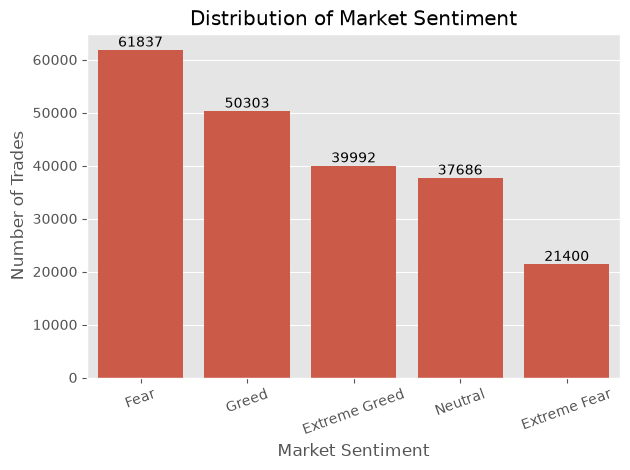

In [108]:
plt.Figure(figsize=(8,5))

ax = sns.countplot(
    data=merge_df_update,
    x="classification",
    order=merge_df_update["classification"].value_counts().index    
            
            )
plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../charts/01_sentiment_distribution.png", dpi=300)
plt.show()

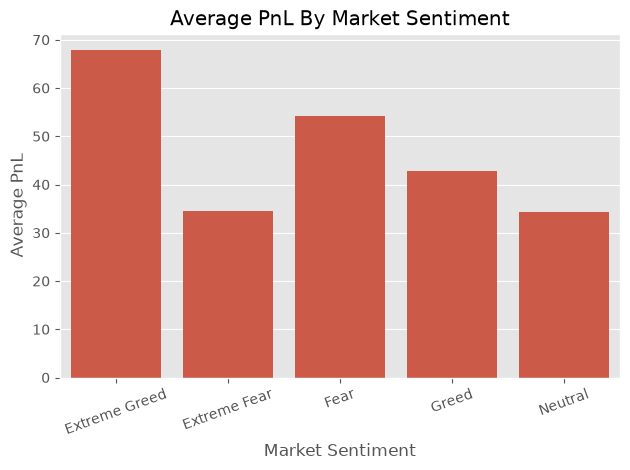

In [109]:
plt.Figure(figsize=(8,5))

sns.barplot(
    data=merge_df_update,
    x="classification",
    y="Closed PnL",
    estimator=np.mean,
    errorbar=None 
            )

plt.title("Average PnL By Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../charts/02_02_avg_pnl.png", dpi=300)
plt.show()

In [110]:
merge_df_update["Profit"] = (merge_df_update["Closed PnL"] > 0).astype(int)

In [111]:
    win_rate = merge_df_update.groupby("classification")["Profit"].mean().sort_values(ascending=False)*100

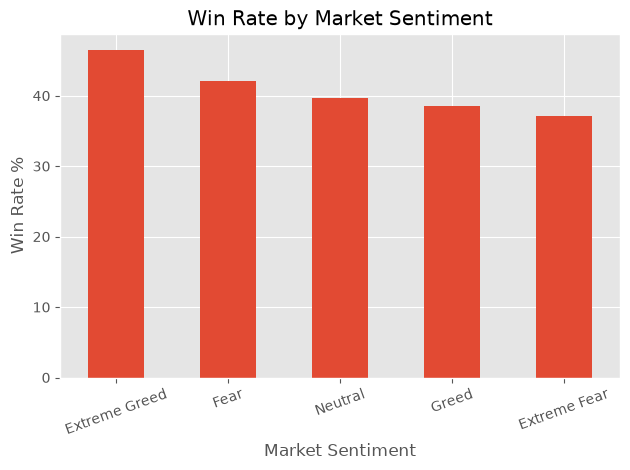

In [112]:
## Win Rate by Market Sentiment
plt.Figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../charts/03_win_rate.png", dpi=300)
plt.show()


In [113]:
merge_df_update

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Date,value,classification,Profit
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,True,0.345404,2024-12-02,80.0,Extreme Greed,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,True,0.005600,2024-12-02,80.0,Extreme Greed,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,True,0.050431,2024-12-02,80.0,Extreme Greed,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,True,0.050043,2024-12-02,80.0,Extreme Greed,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,True,0.003055,2024-12-02,80.0,Extreme Greed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,False,0.042080,2025-04-25,60.0,Greed,0
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,False,0.233863,2025-04-25,60.0,Greed,0
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,False,0.046616,2025-04-25,60.0,Greed,0
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,False,0.396337,2025-04-25,60.0,Greed,0


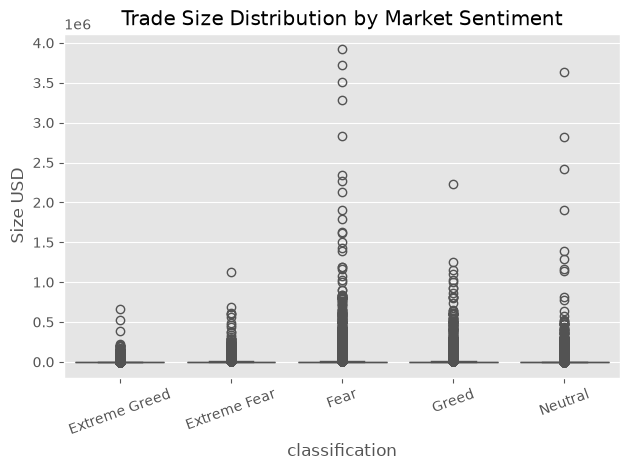

In [116]:
## Trade Size Distribution by Market Sentiment
plt.Figure(figsize=(10,6))

sns.boxplot(
    data=merge_df_update,
    x="classification",
    y="Size USD"
)

plt.title("Trade Size Distribution by Market Sentiment")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../charts/04_trade_size.png", dpi=300)
plt.show()

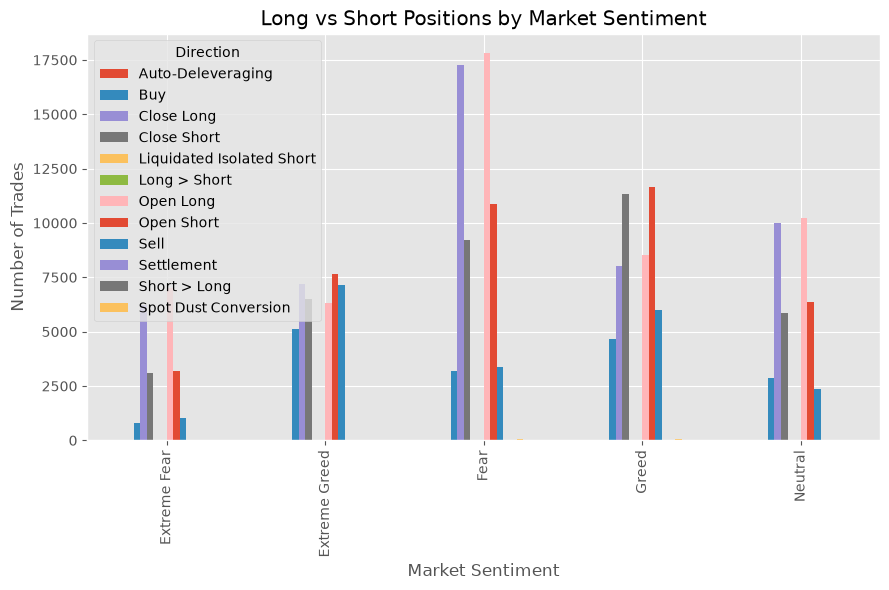

In [119]:
## Long vs Short Positions by Market Sentiment
direction = pd.crosstab(
    merge_df_update["classification"],
    merge_df_update["Direction"]
)

direction.plot(kind="bar",figsize=(9,6))

plt.title("Long vs Short Positions by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.savefig("../charts/05_long_short.png", dpi=300)
plt.show()

In [128]:
## Top 10 Coins by Total Closed PnL
top_coin = merge_df_update.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

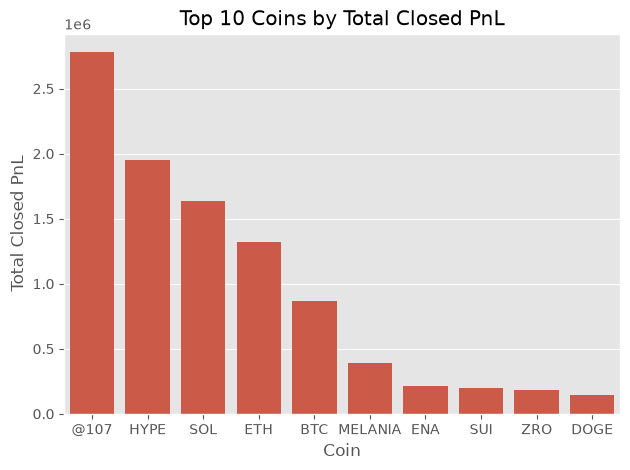

In [132]:
plt.Figure(figsize=(9,6))

sns.barplot(
    x=top_coin.index,
    y=top_coin.values
)

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")
plt.tight_layout()
plt.savefig("../charts/06_top_coins.png", dpi=300)
plt.show()


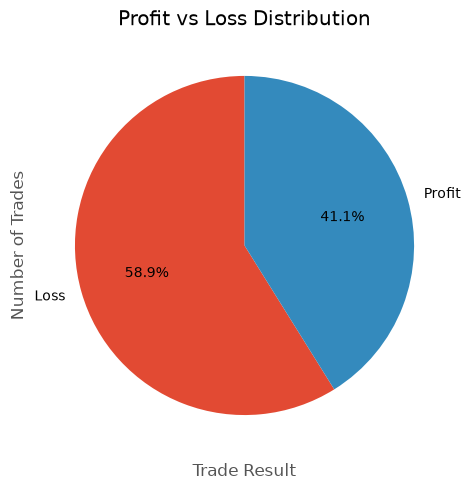

In [141]:
## Profit vs Loss Distribution
profit_loss = merge_df_update["Profit"].value_counts()
plt.figure(figsize=(8,5))

plt.pie(
    profit_loss,
    labels=["Loss","Profit"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Profit vs Loss Distribution")
plt.xlabel("Trade Result")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.savefig("../charts/07_profit_loss.png", dpi=300)

plt.show()

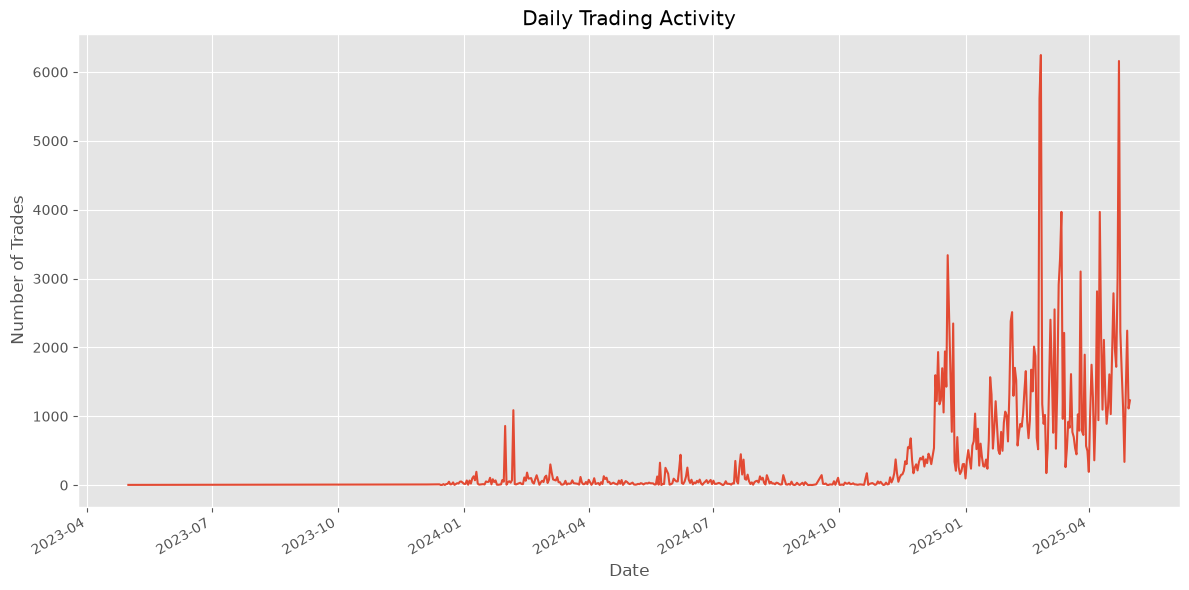

In [137]:
## Daily Trading Activity
daily_trades = merge_df_update.groupby("Date").size()
plt.figure(figsize=(12,6))

daily_trades.plot(kind="line")

plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.savefig("../charts/08_daily_trades.png", dpi=300)

plt.show()


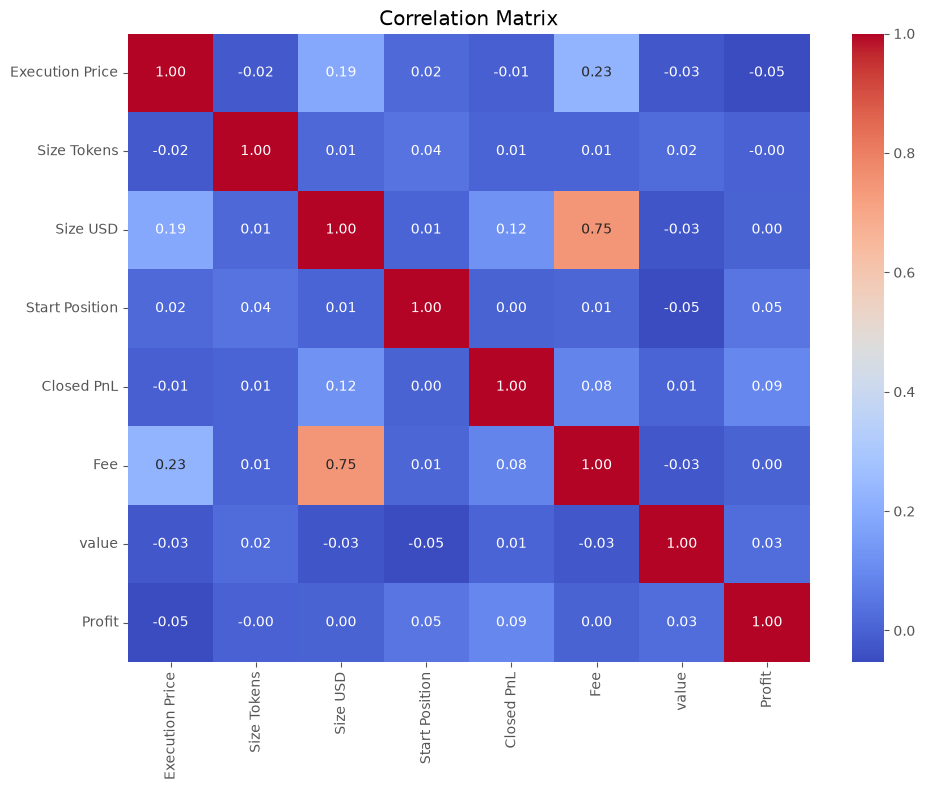

In [149]:
numeric = merge_df_update.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("../charts/09_heatmap.png", dpi=300)

plt.show()

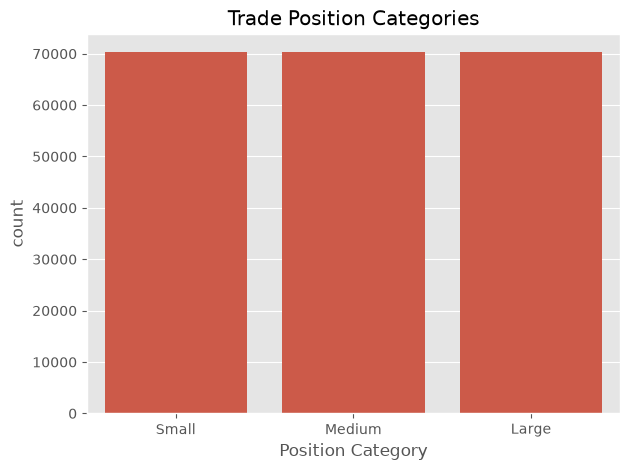

In [150]:
# Create Position Category based on trade size (USD)

merge_df_update["Position Category"] = pd.qcut(
    merge_df_update["Size USD"],
    q=3,
    labels=["Small", "Medium", "Large"],
    duplicates="drop"
)

merge_df_update["Position Category"].value_counts()
sns.countplot(
    data=merge_df_update,
    x="Position Category"
)

plt.title("Trade Position Categories")

plt.tight_layout()

plt.savefig("../charts/10_position_category.png", dpi=300)

plt.show() 

# Key Insights

## Insight 1: Trading activity is highest during Fear and Greed periods.

The distribution of trades shows that the majority of trading activity occurs during **Fear (61,837 trades)** and **Greed (50,303 trades)** market conditions, while **Extreme Fear (21,400 trades)** records the lowest trading activity.

This indicates that traders remain highly active during volatile market phases rather than avoiding the market altogether.

---

## Insight 2: Traders achieve the highest profitability during Extreme Greed.

The average Closed PnL increases significantly during positive market sentiment.

| Sentiment | Average Closed PnL |
|-----------|-------------------:|
| Extreme Greed | 67.89 |
| Fear | 54.29 |
| Greed | 42.74 |
| Extreme Fear | 34.54 |
| Neutral | 34.31 |

This suggests that bullish market conditions generally provide better profit opportunities.

---

## Insight 3: Win rate is highest during Extreme Greed.

The trader win rate follows a similar trend.

| Sentiment | Win Rate (%) |
|-----------|-------------:|
| Extreme Greed | 46.49 |
| Fear | 42.08 |
| Neutral | 39.70 |
| Greed | 38.48 |
| Extreme Fear | 37.06 |

Although no sentiment produces a win rate above 50%, traders perform noticeably better during Extreme Greed than during Extreme Fear.

---

## Insight 4: Fear does not always result in the lowest profitability.

Interestingly, traders generated higher average profits during Fear (54.29) than during normal Greed (42.74).

This may indicate that experienced traders exploit market corrections by entering positions at discounted prices.

Further investigation by trader segment could validate this hypothesis.